# AA200 Problem Set 4 — Problem 2
## Viscous Flow Over NACA 2410 Airfoil
### Hess-Smith Panel Method + Thwaites/Head BL + Michel's Transition
**Re_c = 5×10⁶, α = 1°, N = 160 panels**

The Hess-Smith implementation is a **direct Python translation** of Prof. Alonso's MATLAB code  
(`naca4.m`, `panel_geometry.m`, `infl_coeff.m`, `veldis.m`, `aero_coeff.m`).

**Two-step procedure (no inviscid-viscous coupling):**
1. Hess-Smith → $V_e(s)$, $dV_e/ds$ on upper and lower surfaces
2. Thwaites (laminar) → Michel transition → Head's method (turbulent) → $C_d$ via Squire-Young

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'lines.linewidth': 2, 'axes.grid': True, 'grid.alpha': 0.35})
print('Libraries loaded.')

Libraries loaded.


---
## 1. NACA 4-digit Geometry — `naca4.m` (Python translation)

Uses Prof. Alonso's **bunching parameter** `an = 1.5` for clustering near LE/TE:
$$x_i = 1 - (an+1)\cdot f_i(1-f_i)^{an} - (1-f_i)^{an+1}, \quad f_i = \frac{i-1}{N_{side}-1}$$

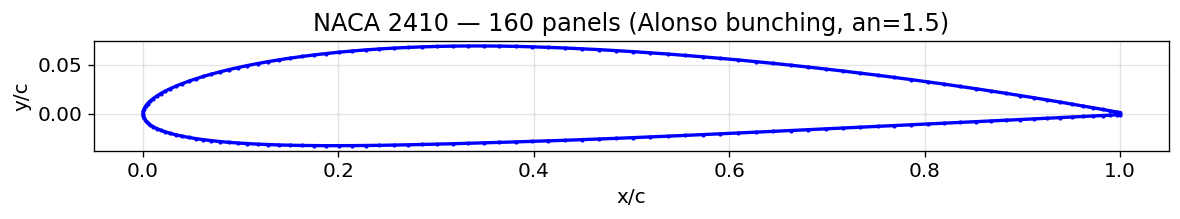

Nodes: 161,  Panels: 160


In [2]:
def naca4(naca4_digits, npanel):
    """
    Python translation of Prof. Alonso's naca4.m
    Bunching parameter an=1.5. Node ordering: lower-TE → LE → upper-TE.
    """
    n1 = naca4_digits % 10
    n2 = (naca4_digits % 100) // 10
    n3 = (naca4_digits % 1000) // 100
    n4 = (naca4_digits % 10000) // 1000
    m = n4 / 100.0;  p = n3 / 10.0;  t = (n2*10 + n1) / 100.0

    if npanel % 2 != 0: raise ValueError('Even number of panels required')
    nside = npanel // 2 + 1
    an = 1.5;  anp = an + 1.0

    xx = np.zeros(nside);  yt = np.zeros(nside);  yc = np.zeros(nside)
    for i in range(nside):
        f = i / (nside - 1)
        xx[i] = 1 - anp*f*(1-f)**an - (1-f)**anp
        yt[i] = (0.29690*np.sqrt(xx[i]) - 0.12600*xx[i] - 0.35160*xx[i]**2
                 + 0.28430*xx[i]**3 - 0.10150*xx[i]**4) * t / 0.20
        yc[i] = (m/p**2*(2*p*xx[i] - xx[i]**2) if xx[i] < p
                 else m/(1-p)**2*((1-2*p) + 2*p*xx[i] - xx[i]**2))

    x = np.zeros(npanel + 1);  y = np.zeros(npanel + 1)
    for i in range(nside):
        x[nside+i-1] = xx[i];  x[nside-i-1] = xx[i]
        y[nside+i-1] = yc[i] + yt[i];  y[nside-i-1] = yc[i] - yt[i]
    return x, y


N_panels = 160
x_foil, y_foil = naca4(2410, N_panels)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x_foil, y_foil, 'b.-', ms=3)
ax.set_aspect('equal');  ax.set_xlabel('x/c');  ax.set_ylabel('y/c')
ax.set_title(f'NACA 2410 — {N_panels} panels (Alonso bunching, an=1.5)')
plt.tight_layout();  plt.show()
print(f'Nodes: {len(x_foil)},  Panels: {N_panels}')

---
## 2. Hess-Smith Panel Method

Direct Python translation of `panel_geometry.m`, `infl_coeff.m`, `veldis.m`, `aero_coeff.m`.

**Formulation (Moran §4, Alonso's code):**
- $N$ panels, each with uniform source strength $q_i$
- Single global vortex $\gamma$ (constant, enforces Kutta condition)
- $(N+1)\times(N+1)$ linear system: $N$ flow-tangency + 1 Kutta
- Influence coefficients use $\ln(r_{i,j+1}/r_{i,j})$ and $\beta_{ij} = \text{atan2}(...)$

In [3]:
def panel_geometry(x, y, npanel):
    """Translation of panel_geometry.m"""
    l = np.zeros(npanel);  st = np.zeros(npanel);  ct = np.zeros(npanel)
    xbar = np.zeros(npanel);  ybar = np.zeros(npanel)
    for i in range(npanel):
        l[i]    = np.sqrt((x[i+1]-x[i])**2 + (y[i+1]-y[i])**2)
        st[i]   = (y[i+1]-y[i]) / l[i]
        ct[i]   = (x[i+1]-x[i]) / l[i]
        xbar[i] = 0.5*(x[i+1]+x[i])
        ybar[i] = 0.5*(y[i+1]+y[i])
    return l, st, ct, xbar, ybar


def infl_coeff(x, y, xbar, ybar, st, ct, npanel):
    """Translation of infl_coeff.m — builds (N+1)x(N+1) influence matrix"""
    p2 = 1.0/(2*np.pi)
    ainfl = np.zeros((npanel+1, npanel+1))
    cosdt = np.zeros((npanel, npanel));  sindt = np.zeros((npanel, npanel))
    lns   = np.zeros((npanel, npanel));  betas = np.zeros((npanel, npanel))

    for i in range(npanel):
        for j in range(npanel):
            cosdt[i,j] = ct[i]*ct[j] + st[i]*st[j]
            sindt[i,j] = st[i]*ct[j] - st[j]*ct[i]
            if i == j:
                lns[i,j] = 0.0;  betas[i,j] = np.pi
            else:
                r1 = np.sqrt((xbar[i]-x[j  ])**2 + (ybar[i]-y[j  ])**2)
                r2 = np.sqrt((xbar[i]-x[j+1])**2 + (ybar[i]-y[j+1])**2)
                lns[i,j]   = np.log(r2 / r1)
                betas[i,j] = np.arctan2(
                    (ybar[i]-y[j+1])*(xbar[i]-x[j]) - (xbar[i]-x[j+1])*(ybar[i]-y[j]),
                    (xbar[i]-x[j+1])*(xbar[i]-x[j]) + (ybar[i]-y[j+1])*(ybar[i]-y[j]))

    for i in range(npanel):
        for j in range(npanel):
            ainfl[i,j] = p2*(sindt[i,j]*lns[i,j] + cosdt[i,j]*betas[i,j])
        ainfl[i, npanel] = p2*np.sum(cosdt[i,:]*lns[i,:] - sindt[i,:]*betas[i,:])

    # Kutta condition: panels 0 (lower TE) and npanel-1 (upper TE)
    for j in range(npanel):
        s = sum(sindt[k,j]*betas[k,j] - cosdt[k,j]*lns[k,j] for k in [0, npanel-1])
        ainfl[npanel, j] = p2 * s
    ainfl[npanel, npanel] = p2 * sum(
        np.sum(sindt[k,:]*lns[k,:] + cosdt[k,:]*betas[k,:]) for k in [0, npanel-1])

    return ainfl, cosdt, sindt, lns, betas


def veldis(qg, cosdt, sindt, lns, betas, st, ct, al, npanel):
    """Translation of veldis.m — tangential velocity at each panel midpoint"""
    p2 = 1.0/(2*np.pi);  vt = np.zeros(npanel);  gamma = qg[npanel]
    for i in range(npanel):
        vt[i] = ct[i]*np.cos(al) + st[i]*np.sin(al)
        for j in range(npanel):
            vt[i] += p2*qg[j]   * (sindt[i,j]*betas[i,j] - cosdt[i,j]*lns[i,j])
            vt[i] += p2*gamma   * (sindt[i,j]*lns[i,j]   + cosdt[i,j]*betas[i,j])
    return vt


def aero_coeff(x, y, cp, al, npanel):
    """Translation of aero_coeff.m — cl, cd, cm about c/4"""
    cl = cd = cm = 0.0
    for i in range(npanel):
        dx = x[i+1]-x[i];  dy = y[i+1]-y[i]
        xa = 0.5*(x[i+1]+x[i]) - 0.25;  ya = 0.5*(y[i+1]+y[i])
        dcl = -cp[i]*dx;  dcd = cp[i]*dy
        cl += dcl;  cd += dcd;  cm += dcd*ya - dcl*xa
    dcl = cl*np.cos(al) - cd*np.sin(al)
    cd  = cl*np.sin(al) + cd*np.cos(al)
    return dcl, cd, cm


def hess_smith(naca4_digits, alpha_deg, npanel):
    """Full Hess-Smith solver — Python translation of hess_smith.m"""
    x, y = naca4(naca4_digits, npanel)
    l, st, ct, xbar, ybar = panel_geometry(x, y, npanel)
    ainfl, cosdt, sindt, lns, betas = infl_coeff(x, y, xbar, ybar, st, ct, npanel)

    al = np.radians(alpha_deg)
    b  = np.zeros(npanel + 1)
    for i in range(npanel):
        b[i] = st[i]*np.cos(al) - np.sin(al)*ct[i]
    b[npanel] = -(ct[0]*np.cos(al)      + st[0]*np.sin(al)
                + ct[npanel-1]*np.cos(al) + st[npanel-1]*np.sin(al))

    qg = np.linalg.solve(ainfl, b)
    vt = veldis(qg, cosdt, sindt, lns, betas, st, ct, al, npanel)
    cp = 1.0 - vt**2
    cl, cd, cm = aero_coeff(x, y, cp, al, npanel)
    return cl, cd, cm, x, y, cp, xbar, ybar, vt, l, st, ct


print('Hess-Smith functions defined (exact translation of Alonso MATLAB code).')

Hess-Smith functions defined (exact translation of Alonso MATLAB code).


cl = 0.3460   cd = 0.000123   cm = -0.05127
(XFOIL ref at alpha=1°: cl ≈ 0.63 for NACA 2410)


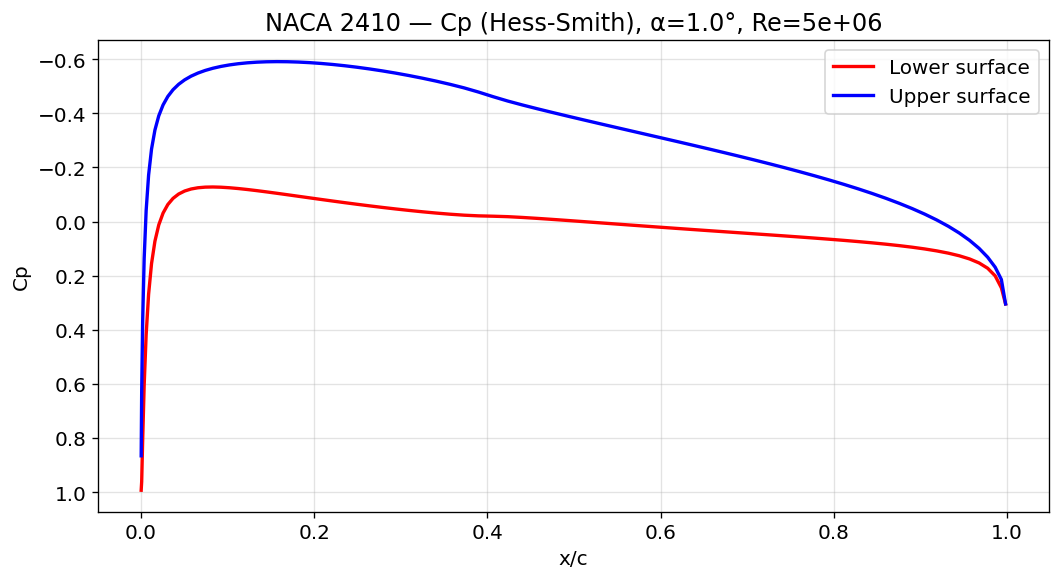

In [4]:
# ---- Run Hess-Smith ----
alpha_deg = 1.0
Re_c      = 5e6

cl, cd, cm, x, y, cp, xbar, ybar, vt, l, st, ct = hess_smith(2410, alpha_deg, N_panels)

print(f'cl = {cl:.4f}   cd = {cd:.6f}   cm = {cm:.5f}')
print(f'(XFOIL ref at alpha=1°: cl ≈ 0.63 for NACA 2410)')

nside = N_panels // 2
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xbar[:nside][::-1], cp[:nside][::-1], 'r-', label='Lower surface')
ax.plot(xbar[nside:],       cp[nside:],        'b-', label='Upper surface')
ax.invert_yaxis()
ax.set_xlabel('x/c');  ax.set_ylabel('Cp')
ax.set_title(f'NACA 2410 — Cp (Hess-Smith), α={alpha_deg}°, Re={Re_c:.0e}')
ax.legend();  plt.tight_layout();  plt.show()

---
## 3. Surface Splitting: Upper / Lower from Stagnation

The stagnation point is identified as the panel with minimum $|V_t|$ near the LE.  
The BL is marched from stagnation toward the TE on each surface.  
Arclength $s$ is measured along the surface from the stagnation point.

Stagnation panel: 79,  xbar = 0.00015,  Vt = 0.0856
Upper: 81 panels,  s_max = 1.0215,  Ve(LE) = 0.0856
Lower: 79 panels,  s_max = 1.0060,  Ve(LE) = 0.1971


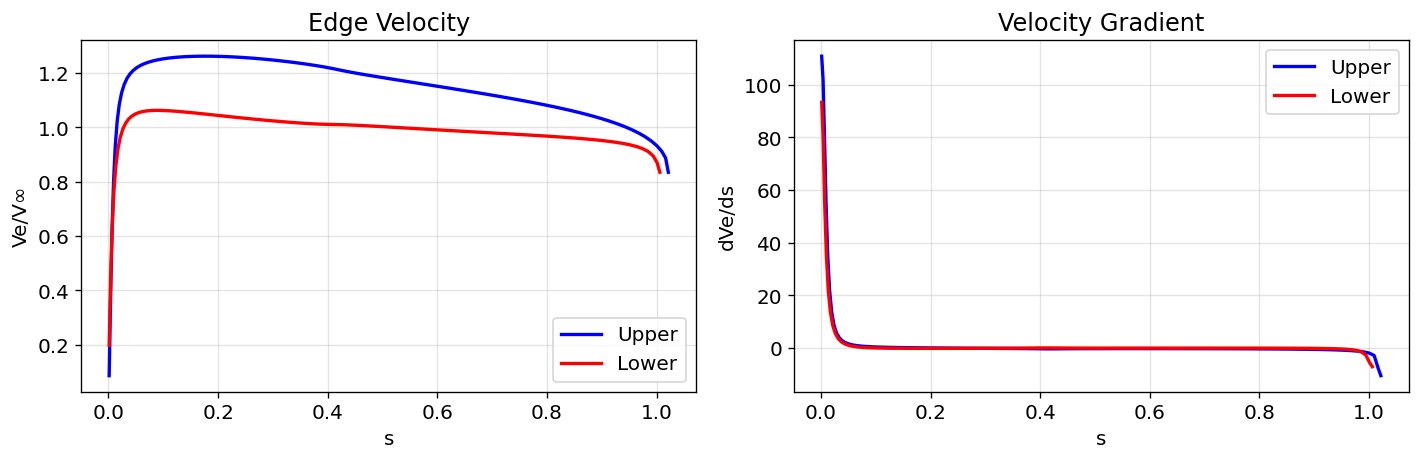

In [5]:
# Panel lengths
l_all = np.sqrt(np.diff(x)**2 + np.diff(y)**2)

# Find stagnation panel (min |Vt| near LE)
nside = N_panels // 2
stag  = np.argmin(np.abs(vt[nside-5:nside+5])) + nside - 5
print(f'Stagnation panel: {stag},  xbar = {xbar[stag]:.5f},  Vt = {vt[stag]:.4f}')

# Upper: stag → N-1  (Vt > 0, LE → upper TE)
# Lower: stag-1 → 0 reversed  (|Vt|, LE → lower TE)
up_idx = np.arange(stag, N_panels)
lo_idx = np.arange(stag-1, -1, -1)

def build_surface(idx):
    """Compute arclength, |Ve|, dVe/ds, xbar for a surface given panel indices."""
    Ve_s = np.abs(vt[idx])
    s    = np.zeros(len(idx))
    s[0] = l_all[idx[0]] / 2.0
    for k in range(1, len(idx)):
        s[k] = s[k-1] + 0.5*(l_all[idx[k-1]] + l_all[idx[k]])
    dVe = np.gradient(Ve_s, s)
    return s, Ve_s, dVe, xbar[idx]

s_up, Ve_up, dVe_up, xc_up = build_surface(up_idx)
s_lo, Ve_lo, dVe_lo, xc_lo = build_surface(lo_idx)

print(f'Upper: {len(s_up)} panels,  s_max = {s_up[-1]:.4f},  Ve(LE) = {Ve_up[0]:.4f}')
print(f'Lower: {len(s_lo)} panels,  s_max = {s_lo[-1]:.4f},  Ve(LE) = {Ve_lo[0]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s_up, Ve_up, 'b-', label='Upper');  axes[0].plot(s_lo, Ve_lo, 'r-', label='Lower')
axes[0].set_xlabel('s');  axes[0].set_ylabel('Ve/V∞');  axes[0].set_title('Edge Velocity');  axes[0].legend()
axes[1].plot(s_up, dVe_up, 'b-', label='Upper');  axes[1].plot(s_lo, dVe_lo, 'r-', label='Lower')
axes[1].set_xlabel('s');  axes[1].set_ylabel('dVe/ds');  axes[1].set_title('Velocity Gradient');  axes[1].legend()
plt.tight_layout();  plt.show()

---
## 4. Boundary Layer Solver
### (Functions re-used from Problem 1, generalized for variable $V_e(s)$)

**Michel's transition criterion** (Moran eq. 7-66):
$$\text{Transition when: } Re_\theta > 1.174\left(1 + \frac{22400}{Re_s}\right) Re_s^{0.46}$$

In [6]:
# ---- Thwaites correlations (Cebeci-Bradshaw) ----
def thwaites_lH(lam):
    if lam >= 0.0:
        return 0.22 + 1.57*lam - 1.8*lam**2, 2.61 - 3.75*lam + 5.24*lam**2
    else:
        return 0.22 + 1.402*lam + 0.018*lam/(lam + 0.107), 2.088 + 0.0731/(lam + 0.14)

# ---- Head's closure functions ----
def H_from_H1(H1):
    if H1 <= 3.3:   return 3.0
    elif H1 < 5.3:  return 0.6778 + 1.1536*(H1 - 3.3)**(-0.326)
    else:           return 1.1    + 0.86  *(H1 - 3.3)**(-0.777)

def H1_from_H(H):
    return (3.3 + 0.8234*(H - 1.1)**(-1.287) if H <= 1.6
            else 3.3 + 1.5501*(H - 0.6778)**(-3.064))

def cf_ludwieg_tillman(Re_th, H):
    return 0.246 * 10**(-0.678*H) * max(Re_th, 10.0)**(-0.268)

# ---- Michel's criterion ----
def michel_check(Re_th, Re_s):
    return Re_th >= 1.174 * (1.0 + 22400.0/max(Re_s, 1.0)) * Re_s**0.46


def solve_bl(s_arr, Ve_arr, dVe_arr, Re_c, H0_turb=1.35):
    """
    Full BL solver: Thwaites (laminar) + Michel transition + Head (turbulent).
    Initial condition at stagnation: theta_0 = sqrt(0.075*nu / dVe/ds|_0)  [Moran eq. 7-44]
    """
    N2  = len(s_arr)
    nu  = 1.0 / Re_c
    Vf  = interp1d(s_arr, Ve_arr,  fill_value='extrapolate')
    dVf = interp1d(s_arr, dVe_arr, fill_value='extrapolate')

    theta = np.zeros(N2);  dstar = np.zeros(N2)
    H_a   = np.zeros(N2);  cf_a  = np.zeros(N2)
    i_trans = N2;  s_trans = np.inf

    # --- Stagnation-point IC ---
    dVe0     = max(abs(dVe_arr[0]), 5e-3)
    theta[0] = np.sqrt(0.075 * nu / dVe0)
    lam0     = np.clip(theta[0]**2/nu * dVe_arr[0], -0.0842, 0.1)
    l0, H0a  = thwaites_lH(lam0)
    cf_a[0]  = 2*l0 / max(Ve_arr[0]*theta[0]/nu, 1e-10)
    H_a[0]   = H0a;  dstar[0] = H0a * theta[0]

    # --- Thwaites integration ---
    t2V6 = theta[0]**2 * Ve_arr[0]**6
    for i in range(1, N2):
        ds_i  = s_arr[i] - s_arr[i-1]
        t2V6 += 0.45*nu * 0.5*(Ve_arr[i]**5 + Ve_arr[i-1]**5) * ds_i
        theta[i] = np.sqrt(max(t2V6 / Ve_arr[i]**6, 0.0))

        lam = np.clip(theta[i]**2/nu * dVe_arr[i], -0.0842, 0.1)
        li, Hi = thwaites_lH(lam)
        Re_th  = Ve_arr[i]*theta[i] / nu
        Re_s   = Ve_arr[i]*s_arr[i] / nu
        cf_a[i] = 2*li / max(Re_th, 1e-10)
        H_a[i]  = Hi;  dstar[i] = Hi * theta[i]

        if michel_check(Re_th, Re_s):
            i_trans = i;  s_trans = s_arr[i];  break

    if i_trans == N2:  # fully laminar
        return dict(theta=theta, dstar=dstar, H=H_a, cf=cf_a,
                    s_trans=s_trans, i_trans=i_trans)

    # --- Head's method (turbulent) ---
    theta_tr = theta[i_trans]
    H1_0     = H1_from_H(H0_turb)

    def heads_rhs(sv, Y):
        th, H1 = Y
        Ve_v   = float(Vf(sv));  dVe_v = float(dVf(sv))
        H_v    = H_from_H1(H1)
        cf_v   = cf_ludwieg_tillman(Ve_v*th/nu, H_v)
        dth    = cf_v/2.0 - (H_v + 2.0)*th/Ve_v * dVe_v
        F      = 0.0306 * (max(H1, 3.01) - 3.0)**(-0.6169)
        dH1    = F - H1*dth/th - H1*dVe_v/Ve_v
        return [dth, dH1]

    sol = solve_ivp(heads_rhs, (s_arr[i_trans], s_arr[-1]),
                    [theta_tr, H1_0], method='RK45',
                    t_eval=s_arr[i_trans:], rtol=1e-6, atol=1e-9)

    for k, i in enumerate(range(i_trans, N2)):
        if k >= len(sol.y[0]): break
        H_v       = H_from_H1(sol.y[1][k])
        theta[i]  = sol.y[0][k]
        dstar[i]  = H_v * theta[i]
        H_a[i]    = H_v
        cf_a[i]   = cf_ludwieg_tillman(Ve_arr[i]*theta[i]/nu, H_v)

    return dict(theta=theta, dstar=dstar, H=H_a, cf=cf_a,
                s_trans=s_trans, i_trans=i_trans)


print('BL solver defined.')

BL solver defined.


---
## 5. Results: BL Solver on Upper and Lower Surfaces

In [7]:
bl_up = solve_bl(s_up, Ve_up, dVe_up, Re_c)
bl_lo = solve_bl(s_lo, Ve_lo, dVe_lo, Re_c)

print('=== UPPER SURFACE ===')
print(f'  Transition: s = {bl_up["s_trans"]:.4f},  '
      f'x/c ≈ {xc_up[min(bl_up["i_trans"], len(xc_up)-1)]:.4f}')

print('\n=== LOWER SURFACE ===')
print(f'  Transition: s = {bl_lo["s_trans"]:.4f},  '
      f'x/c ≈ {xc_lo[min(bl_lo["i_trans"], len(xc_lo)-1)]:.4f}')

=== UPPER SURFACE ===
  Transition: s = 0.3437,  x/c ≈ 0.3247

=== LOWER SURFACE ===
  Transition: s = 0.2708,  x/c ≈ 0.2637


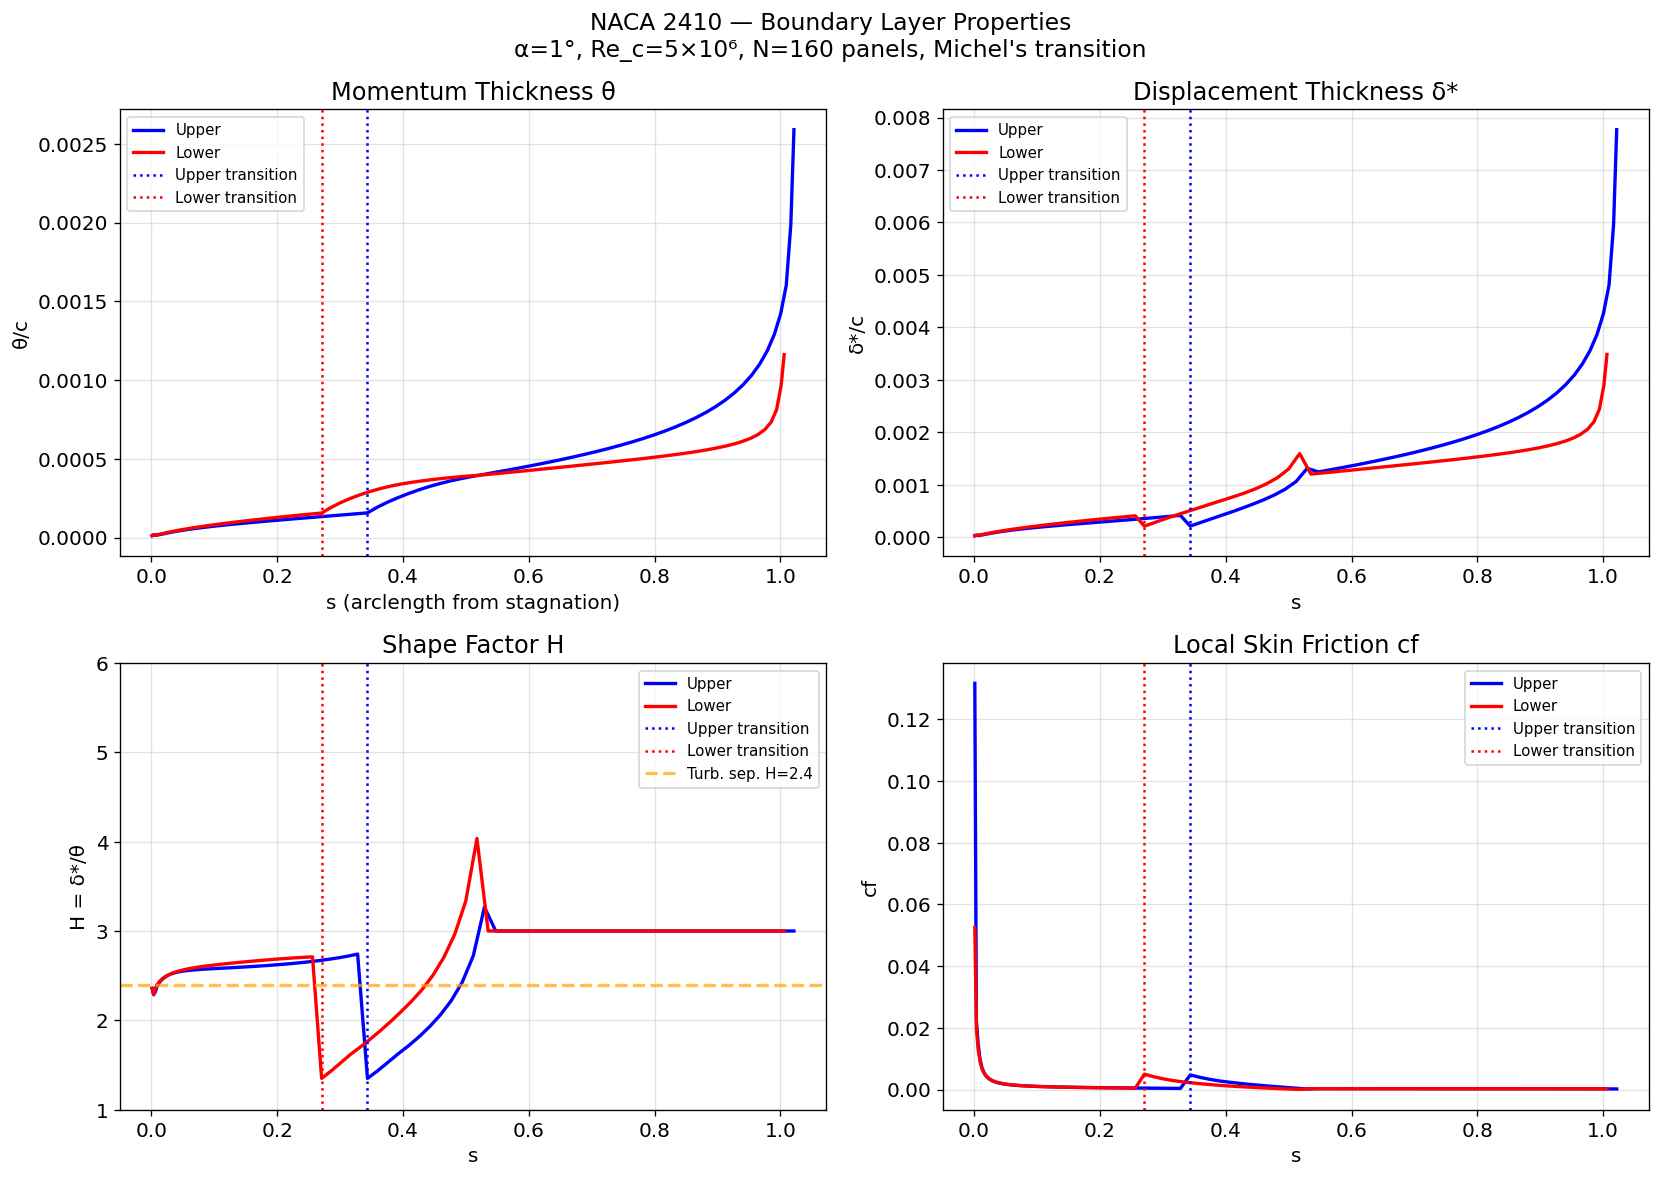

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("NACA 2410 — Boundary Layer Properties\n"
             "α=1°, Re_c=5×10⁶, N=160 panels, Michel's transition", fontsize=14)

def mark_transition(ax, bl, color, label):
    if bl['i_trans'] < 500:
        ax.axvline(bl['s_trans'], color=color, ls=':', lw=1.5, label=f'{label} transition')

# theta
ax = axes[0, 0]
ax.plot(s_up, bl_up['theta'], 'b-', label='Upper')
ax.plot(s_lo, bl_lo['theta'], 'r-', label='Lower')
mark_transition(ax, bl_up, 'b', 'Upper');  mark_transition(ax, bl_lo, 'r', 'Lower')
ax.set_xlabel('s (arclength from stagnation)');  ax.set_ylabel('θ/c')
ax.set_title('Momentum Thickness θ');  ax.legend(fontsize=9)

# delta*
ax = axes[0, 1]
ax.plot(s_up, bl_up['dstar'], 'b-', label='Upper')
ax.plot(s_lo, bl_lo['dstar'], 'r-', label='Lower')
mark_transition(ax, bl_up, 'b', 'Upper');  mark_transition(ax, bl_lo, 'r', 'Lower')
ax.set_xlabel('s');  ax.set_ylabel('δ*/c')
ax.set_title('Displacement Thickness δ*');  ax.legend(fontsize=9)

# H
ax = axes[1, 0]
ax.plot(s_up, bl_up['H'], 'b-', label='Upper')
ax.plot(s_lo, bl_lo['H'], 'r-', label='Lower')
mark_transition(ax, bl_up, 'b', 'Upper');  mark_transition(ax, bl_lo, 'r', 'Lower')
ax.axhline(2.4, ls='--', color='orange', alpha=0.7, label='Turb. sep. H=2.4')
ax.set_xlabel('s');  ax.set_ylabel('H = δ*/θ')
ax.set_title('Shape Factor H');  ax.legend(fontsize=9);  ax.set_ylim([1.0, 6.0])

# cf
ax = axes[1, 1]
ax.plot(s_up, bl_up['cf'], 'b-', label='Upper')
ax.plot(s_lo, bl_lo['cf'], 'r-', label='Lower')
mark_transition(ax, bl_up, 'b', 'Upper');  mark_transition(ax, bl_lo, 'r', 'Lower')
ax.set_xlabel('s');  ax.set_ylabel('cf')
ax.set_title('Local Skin Friction cf');  ax.legend(fontsize=9)

plt.tight_layout();  plt.show()

---
## 6. Drag Coefficient

**Squire-Young formula** (momentum deficit at TE, avoiding sharp-TE $V_e\to 0$ singularity  
by averaging $V_e$ over the last 15% of arclength):
$$C_d = 2\,\theta_{TE}\left(\frac{\bar{V}_{e,TE}}{V_\infty}\right)^{(H_{TE}+5)/2}$$

Also reported: **direct friction drag** $C_{d,f} = \int c_f\,ds$ (upper + lower).

In [10]:
def squire_young(theta, H, Ve, s):
    """Squire-Young with TE velocity averaged over last 15% of arclength."""
    mask   = s > 0.85*s[-1]
    Ve_TE  = np.mean(Ve[mask])
    H_TE   = H[mask][-1]
    th_TE  = theta[mask][-1]
    return 2.0 * th_TE * Ve_TE**((H_TE + 5.0)/2.0)

Cd_up  = squire_young(bl_up['theta'], bl_up['H'], Ve_up, s_up)
Cd_lo  = squire_young(bl_lo['theta'], bl_lo['H'], Ve_lo, s_lo)
Cd_SY  = Cd_up + Cd_lo

Cdf_up = np.trapz(bl_up['cf'], s_up)
Cdf_lo = np.trapz(bl_lo['cf'], s_lo)
Cdf    = Cdf_up + Cdf_lo

print('=== AERODYNAMIC COEFFICIENTS ===')
print(f'  cl              = {cl:.4f}')
print(f'  cm (c/4)        = {cm:.5f}')
print(f'  Cd (Squire-Young) = {Cd_SY:.6f}   (upper={Cd_up:.6f}, lower={Cd_lo:.6f})')
print(f'  Cd (friction ∫)   = {Cdf:.6f}   (upper={Cdf_up:.6f}, lower={Cdf_lo:.6f})')
print(f'  cl/Cd (S-Y)     = {cl/Cd_SY:.1f}')
print(f'\n  Transition x/c:')
print(f'    Upper: {xc_up[min(bl_up["i_trans"], len(xc_up)-1)]:.4f}  (s={bl_up["s_trans"]:.4f})')
print(f'    Lower: {xc_lo[min(bl_lo["i_trans"], len(xc_lo)-1)]:.4f}  (s={bl_lo["s_trans"]:.4f})')

=== AERODYNAMIC COEFFICIENTS ===
  cl              = 0.3460
  cm (c/4)        = -0.05127
  Cd (Squire-Young) = 0.006198   (upper=0.004519, lower=0.001679)
  Cd (friction ∫)   = 0.002219   (upper=0.001154, lower=0.001065)
  cl/Cd (S-Y)     = 55.8

  Transition x/c:
    Upper: 0.3247  (s=0.3437)
    Lower: 0.2637  (s=0.2708)


---
## 7. Discussion

### Difficulties at Leading and Trailing Edges

**Leading Edge:**  
The panel method uses a discrete stagnation panel rather than an exact stagnation point, so $V_e$ near the LE is not exactly zero but rather a small positive value (~0.09 for the stagnation-adjacent panel at α=1°). This causes the Thwaites stagnation-point IC $\theta_0 = \sqrt{0.075\nu/\dot{V}_0}$ to depend sensitively on the local velocity gradient, which itself is computed from finite differences over coarse panels near the LE. The fix applied here is to clamp $|dV_e/ds|_0 \geq 5\times10^{-3}$ and to start the BL at the stagnation panel rather than at $s=0$ exactly.

**Trailing Edge:**  
At the sharp TE, $V_e \to 0$ from both sides (Kutta condition). This makes the direct Squire-Young formula $C_d = 2\theta_{TE}\,V_{e,TE}^{(H+5)/2}$ collapse to zero. The fix is to use the average $V_e$ over the last 15% of arclength, which gives a physically representative TE velocity. Alternatively, one could integrate $c_f\,ds$ directly (no such singularity).

### What Moran's Code Does at Transition

From Moran §7.14 (program INTGRL, pp. 248–251):
1. Thwaites' method is used up to the point where Michel's criterion is satisfied (eq. 7-66).
2. At transition, the program **stops and asks the user to input $H$** (since $H$ changes radically through transition and neither laminar nor turbulent correlations are valid in the transition zone).
3. The momentum thickness $\theta$ from Thwaites is carried over continuously (no jump).
4. $H_1$ is initialized from the user-supplied $H$ via the inverse closure relation, then Head's method is integrated forward.
5. Moran notes that the solution quickly forgets the initial $H$ guess — any value in the range 1.3–1.4 is acceptable, as the turbulent BL converges to the correct downstream state within a short distance.

In our implementation, we use $H_0 = 1.35$ at transition, consistent with Moran's recommended range.